In [1]:
%%capture
!pip install unsloth torchvision pillow --upgrade
!pip install rouge_score sentence_transformers
!pip install sacrebleu bert-score torch transformers

In [2]:
import os
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig
from datasets import Dataset
from PIL import Image
import json, random
from pathlib import Path

# ── Config ────────────────────────────────────────────────────────────────────
DRIVE_BASE  = Path(".")
PHOTOS_DIR  = DRIVE_BASE / "photos"
JSON_PATH   = DRIVE_BASE / "descriptions.json"
ADAPTER_DIR = DRIVE_BASE / "adapter"
EVALUATION_PATH = DRIVE_BASE / "eval_captions.json"
EVAL_METRICS_PATH = DRIVE_BASE / "evaluation_metrics.json"
LANG        = "lt"  # "en" or "lt"


/usr/lib/python3/dist-packages/google/protobuf/__init__.py:37: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [3]:
# ── Load JSON ─────────────────────────────────────────────────────────────────
with open(JSON_PATH, "r", encoding="utf-8") as f:
    raw = json.load(f)

records = []
for v in raw.values():
    if v.get("status") == "done":
        # The JSON has hardcoded paths. Swap the old base for the actual DRIVE_BASE.
        original_path = v["file"]
        fixed_path = original_path.replace("/content/drive/MyDrive/team", str(DRIVE_BASE))
        
        # Check if file exists to avoid FileNotFoundError later
        if not os.path.exists(fixed_path):
            print(f"⚠️  File not found, skipping: {fixed_path}")
            continue

        records.append({
            "image_path": fixed_path,
            "caption": v[f"description_{LANG}"]
        })

print(f"✅  {len(records)} training records loaded")


⚠️  File not found, skipping: ./photos/20260523_130701 (1).jpg
✅  149 training records loaded


In [4]:
# ── Train / eval split ────────────────────────────────────────────────────────
random.shuffle(records)
split       = max(1, int(len(records) * 0.8))
train_data  = records[:split]
eval_data   = records[split:] or records[:1]  # fallback if tiny dataset
print(f"   Train: {len(train_data)}  |  Eval: {len(eval_data)}")

   Train: 119  |  Eval: 30


In [5]:
from transformers import TrainerCallback
from sentence_transformers import SentenceTransformer, util
from rouge_score import rouge_scorer
import torch

INSTRUCTION = (
    "Describe this image in detail in plain prose. "
    "Cover the main subject, setting, colors, mood, and notable details. "
    "Do not use markdown or bullet points."
)

# 1. Create a lightweight validation probe set (fixed subset for monitoring)
PROBE_SIZE = 10
probe_data = eval_data[:PROBE_SIZE]
print(f"🎯 Created fixed probe set with {len(probe_data)} images for live monitoring.")

# 2. Implement the TrainerCallback
class OverfittingMonitorCallback(TrainerCallback):
    def __init__(self, probe_set, model, processor, instruction, eval_steps=20, history_path=None):
        self.probe_set = probe_set
        self.model = model
        self.processor = processor
        self.instruction = instruction
        self.eval_steps = eval_steps
        self.history_path = history_path
        # Lightweight similarity model
        self.sim_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
        self.rouge_sc = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=False)
        self.history = []
        
        # Try to load existing history
        if self.history_path and os.path.exists(self.history_path):
            try:
                with open(self.history_path, "r") as f:
                    self.history = json.load(f)
                print(f"📈 Loaded existing monitor history ({len(self.history)} entries)")
            except:
                pass

        self.best_score = max([h["sim"] for h in self.history]) if self.history else -1
        self.patience_counter = 0

    def on_step_end(self, args, state, control, **kwargs):
        if state.global_step > 0 and state.global_step % self.eval_steps == 0:
            self.run_eval(state.global_step)

    def run_eval(self, step):
        # Temporarily switch to eval mode
        self.model.eval()
        sim_scores = []
        rouge_scores = []
        
        print(f"\n🔍 [Step {step}] Running probe evaluation...")
        for record in self.probe_set:
            try:
                img = Image.open(record["image_path"]).convert("RGB")
                messages = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": self.instruction}]}]
                text = self.processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
                inputs = self.processor(images=[img], text=text, return_tensors="pt").to("cuda")
                
                with torch.no_grad():
                    # Keep generation short and fast for monitoring
                    outputs = self.model.generate(**inputs, max_new_tokens=100, temperature=0.2)
                
                gen_text = self.processor.decode(outputs[0], skip_special_tokens=True).split("assistant")[-1].strip()
                
                # 1. Semantic Similarity
                emb_ref = self.sim_model.encode(record["caption"], convert_to_tensor=True)
                emb_gen = self.sim_model.encode(gen_text, convert_to_tensor=True)
                similarity = float(util.cos_sim(emb_ref, emb_gen))
                sim_scores.append(similarity)
                
                # 2. ROUGE-L
                r = self.rouge_sc.score(record["caption"], gen_text)["rougeL"].fmeasure
                rouge_scores.append(r)
                
            except Exception as e:
                continue
            
        if sim_scores:
            avg_sim = sum(sim_scores) / len(sim_scores)
            avg_rouge = sum(rouge_scores) / len(rouge_scores)
            self.history.append({"step": step, "sim": avg_sim, "rouge": avg_rouge})
            
            # Save history to disk
            if self.history_path:
                os.makedirs(os.path.dirname(self.history_path), exist_ok=True)
                with open(self.history_path, "w") as f:
                    json.dump(self.history, f)

            # Using Semantic Similarity as the primary indicator for overfitting logic
            if avg_sim > self.best_score + 0.001:
                self.best_score = avg_sim
                self.patience_counter = 0
            else:
                self.patience_counter += 1
                if self.patience_counter >= 3:
                    print(f"🚨 Possible overfitting detected: validation plateau at step {step}")

        # Return to training mode
        self.model.train()

def gen_dataset(data_list):
    for record in data_list:
        try:
            img = Image.open(record["image_path"]).convert("RGB")
            img.thumbnail((768, 768))

            yield {
                "messages": [
                    {"role": "user",      "content": [{"type": "image"}, {"type": "text", "text": INSTRUCTION}]},
                    {"role": "assistant", "content": [{"type": "text",  "text": record["caption"]}]},
                ],
                "images": [img],
            }
        except Exception as e:
            print(f"⚠️ Skipping broken image {record.get('image_path', 'Unknown')}: {e}")
            continue

train_ds = Dataset.from_generator(lambda: gen_dataset(train_data))
eval_ds  = Dataset.from_generator(lambda: gen_dataset(eval_data))

model, processor = FastVisionModel.from_pretrained(
    "unsloth/Qwen3-VL-2B-Instruct",
    load_in_4bit=False,
    torch_dtype="bfloat16",
    use_gradient_checkpointing="unsloth",
)

# Lower LoRA VRAM footprint
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = False,
    finetune_language_layers   = True,
    finetune_attention_modules = True,
    finetune_mlp_modules       = True,
    r=32, lora_alpha=32,
    lora_dropout=0, bias="none",
    random_state=42,
)

# Detect latest checkpoint
last_checkpoint = None
if os.path.exists(ADAPTER_DIR):
    checkpoints = [d for d in os.listdir(ADAPTER_DIR) if d.startswith("checkpoint-")]
    if checkpoints:
        checkpoints.sort(key=lambda x: int(x.split("-")[1]))
        last_checkpoint = str(ADAPTER_DIR / checkpoints[-1])
        print(f"🔄 Found latest checkpoint: {last_checkpoint}")

# If starting fresh, wipe the old monitor history so the plot doesn't mix runs
monitor_history_path = str(ADAPTER_DIR / "monitor_history.json")
if last_checkpoint is None and os.path.exists(monitor_history_path):
    os.remove(monitor_history_path)
    print("🧹 Cleared old monitor history (starting fresh training)")

# 4. Training integration
monitor_callback = OverfittingMonitorCallback(
    probe_set=probe_data,
    model=model,
    processor=processor,
    instruction=INSTRUCTION,
    eval_steps=20,
    history_path=monitor_history_path
)

# Detect latest checkpoint
last_checkpoint = None
if os.path.exists(ADAPTER_DIR):
    checkpoints = [d for d in os.listdir(ADAPTER_DIR) if d.startswith("checkpoint-")]
    if checkpoints:
        checkpoints.sort(key=lambda x: int(x.split("-")[1]))
        last_checkpoint = str(ADAPTER_DIR / checkpoints[-1])
        print(f"🔄 Found latest checkpoint: {last_checkpoint}")

# Trainer Config
trainer = SFTTrainer(
    model         = model,
    tokenizer     = processor,
    train_dataset = train_ds,
    eval_dataset  = eval_ds,
    data_collator = UnslothVisionDataCollator(model, processor),
    callbacks     = [monitor_callback],
    args          = SFTConfig(
        output_dir                  = str(ADAPTER_DIR),
        num_train_epochs            = 8,
        per_device_train_batch_size = 1,
        gradient_accumulation_steps = 4,
        
        warmup_steps                = 30,
        learning_rate               = 1e-4,
        
        fp16                        = True,
        bf16                        = False,
        optim                       = "adamw_8bit", # Crucial for 8-bit memory states
        
        logging_steps               = 1,
        eval_strategy               = "epoch",
        save_strategy               = "epoch",
        save_total_limit            = 2,            # Only keep last 2 checkpoints to save space
        load_best_model_at_end      = True,
        
        report_to                   = "none",
        remove_unused_columns       = False,
        dataset_text_field          = "",
        dataset_kwargs              = {"skip_prepare_dataset": True},
    ),
)

print(f"🚀 Finetuning {'from checkpoint' if last_checkpoint else 'from scratch'}...")
trainer.train(resume_from_checkpoint=last_checkpoint)

model.save_pretrained(str(ADAPTER_DIR))
processor.save_pretrained(str(ADAPTER_DIR))
print(f"💾  Adapter saved → {ADAPTER_DIR}")

🎯 Created fixed probe set with 10 images for live monitoring.


Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

==((====))==  Unsloth 2026.6.1: Fast Qwen3_Vl patching. Transformers: 5.5.0.
   \\   /|    Tesla V100-SXM2-32GB. Num GPUs = 1. Max memory: 31.733 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

...


🔍 [Step 200] Running probe evaluation...
🚨 Possible overfitting detected: validation plateau at step 200


Unsloth: Restored added_tokens_decoder metadata in adapter/checkpoint-210/tokenizer_config.json.



🔍 [Step 220] Running probe evaluation...
🚨 Possible overfitting detected: validation plateau at step 220

🔍 [Step 240] Running probe evaluation...
🚨 Possible overfitting detected: validation plateau at step 240


Unsloth: Restored added_tokens_decoder metadata in adapter/checkpoint-240/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in adapter/tokenizer_config.json.


💾  Adapter saved → adapter


/scratch/lustre/home/tari9925/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


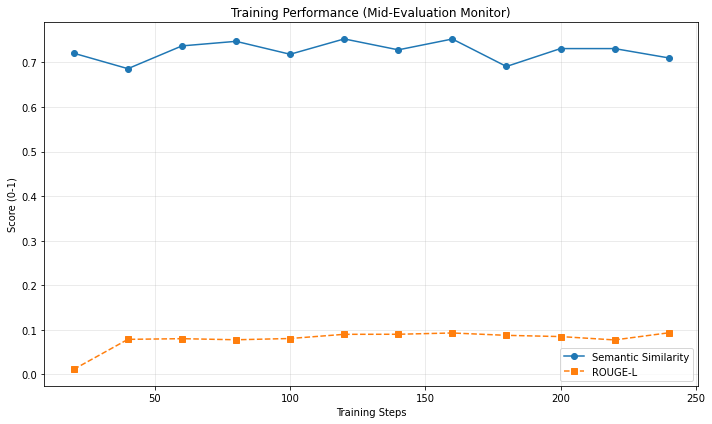

In [6]:

# ── Plot Live Evaluation History ─────────────────────────────────────────────
import matplotlib.pyplot as plt
if hasattr(monitor_callback, 'history') and monitor_callback.history:
    steps = [h['step'] for h in monitor_callback.history]
    sim_scores = [h['sim'] for h in monitor_callback.history]
    rouge_scores = [h['rouge'] for h in monitor_callback.history]

    plt.figure(figsize=(10, 6))
    
    # Plot Semantic Similarity
    plt.plot(steps, sim_scores, marker='o', linestyle='-', color='#1f77b4', label='Semantic Similarity')
    
    # Plot ROUGE-L
    plt.plot(steps, rouge_scores, marker='s', linestyle='--', color='#ff7f0e', label='ROUGE-L')

    plt.title('Training Performance (Mid-Evaluation Monitor)')
    plt.xlabel('Training Steps')
    plt.ylabel('Score (0-1)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No training history found in monitor_callback. Ensure training has run.")


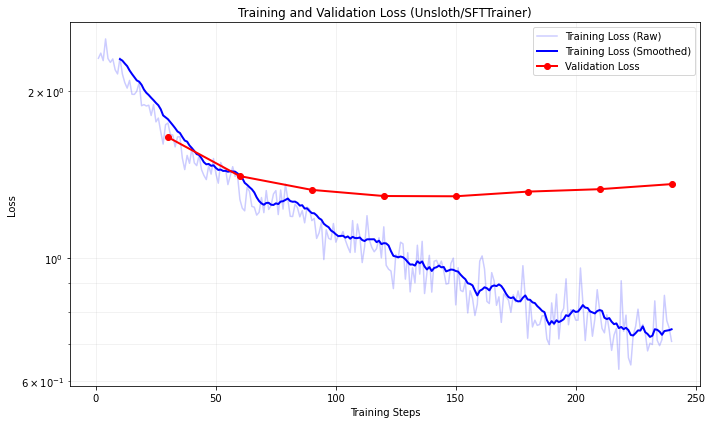

In [7]:

# ── Plot Trainer Loss History (Training vs Validation) ───────────────────────
import pandas as pd
import matplotlib.pyplot as plt

# Extract metrics from trainer state logs
history = trainer.state.log_history

train_loss = []
val_loss = []

for entry in history:
    if 'loss' in entry:
        train_loss.append({'step': entry['step'], 'loss': entry['loss']})
    if 'eval_loss' in entry:
        val_loss.append({'step': entry['step'], 'loss': entry['eval_loss']})

if train_loss:
    df_train = pd.DataFrame(train_loss)
    df_val = pd.DataFrame(val_loss)

    plt.figure(figsize=(10, 6))
    
    # Plot raw training loss with low alpha
    plt.plot(df_train['step'], df_train['loss'], label='Training Loss (Raw)', color='blue', alpha=0.2)
    
    # Plot smoothed training loss for better trend visibility
    if len(df_train) > 10:
        plt.plot(df_train['step'], df_train['loss'].rolling(window=10).mean(), label='Training Loss (Smoothed)', color='blue', linewidth=2)
    
    # Plot validation loss (usually much fewer points, at epoch ends)
    if not df_val.empty:
        plt.plot(df_val['step'], df_val['loss'], label='Validation Loss', marker='o', color='red', linewidth=2)

    plt.title('Training and Validation Loss (Unsloth/SFTTrainer)')
    plt.xlabel('Training Steps')
    plt.ylabel('Loss')
    plt.yscale('log') # Losses often vary exponentially; log scale helps visibility
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No trainer loss history found. Ensure trainer.train() has completed.")


In [8]:
# Generate Captions using BOTH base and finetuned model
import json
from pathlib import Path
from PIL import Image
import torch

FastVisionModel.for_inference(model)

results = []
print(f"🚀 Starting inference on {len(eval_data)} images (Comparing Base vs Finetuned)...")

for record in eval_data:
    try:
        img = Image.open(record["image_path"]).convert("RGB")

        messages = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": INSTRUCTION}]}]
        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = processor(images=[img], text=text, return_tensors="pt").to("cuda")

        # 1. Finetuned Model Inference
        with torch.no_grad():
            out_ft = model.generate(**inputs, max_new_tokens=512, temperature=0.7)
        gen_ft = processor.decode(out_ft[0], skip_special_tokens=True).split("assistant")[-1].strip()

        # 2. Base Model Inference (using disable_adapter)
        with torch.no_grad():
            with model.disable_adapter():
                out_base = model.generate(**inputs, max_new_tokens=512, temperature=0.7)
        gen_base = processor.decode(out_base[0], skip_special_tokens=True).split("assistant")[-1].strip()

        results.append({
            "img_path": record["image_path"],
            "reference": record["caption"],
            "base_generated": gen_base,
            "finetuned_generated": gen_ft
        })
    except Exception as e:
        print(f"⚠️ Skipping missing/broken image {record.get('image_path', 'Unknown')}: {e}")
        continue

with open(EVALUATION_PATH, "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print(f"✅ Inference complete. Results saved to {EVALUATION_PATH}")


🚀 Starting inference on 30 images (Comparing Base vs Finetuned)...
✅ Inference complete. Results saved to eval_captions.json


In [9]:
import json
import math
from pathlib import Path
import torch
from sentence_transformers import SentenceTransformer, util
from rouge_score import rouge_scorer
import sacrebleu
from bert_score import scorer as bert_scorer
from transformers import AutoModelForCausalLM, AutoTokenizer

# ── Config & Setup ────────────────────────────────────────────────────────────
with open(EVALUATION_PATH, "r", encoding="utf-8") as f:
    eval_data = json.load(f)

# 1. Base Metrics
rouge_sc = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=False)
sem_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

# 2. BERTScore Configuration
bs_scorer = bert_scorer.BERTScorer(lang="lt", model_type="xlm-roberta-base", num_layers=9)

# 3. Perplexity Configuration
# Using XGLM (a proper multilingual decoder) for valid perplexity calculation in Lithuanian
ppl_model_name = "facebook/xglm-564M"
ppl_tokenizer = AutoTokenizer.from_pretrained(ppl_model_name)
ppl_model = AutoModelForCausalLM.from_pretrained(ppl_model_name).to("cuda" if torch.cuda.is_available() else "cpu")
ppl_model.eval()

# Metrics storage for both types
metrics = {
    "base": {"rouge": [], "sem": [], "bleu": [], "bert": [], "ppl": []},
    "ft":   {"rouge": [], "sem": [], "bleu": [], "bert": [], "ppl": []}
}

enriched_records = []

print(f"📊 Benchmarking {len(eval_data)} items (Base vs Finetuned) in Lithuanian...\n")

def calculate_perplexity(text, model, tokenizer):
    if not text.strip(): return float('nan')
    try:
        encodings = tokenizer(text, return_tensors="pt")
        input_ids = encodings.input_ids.to(model.device)
        target_ids = input_ids.clone()
        
        with torch.no_grad():
            outputs = model(input_ids, labels=target_ids)
            neg_log_likelihood = outputs.loss
        
        return math.exp(neg_log_likelihood.item())
    except Exception as e:
        # Ignore extremely long sequences that might OOM or exceed context
        return float('nan')

for item in eval_data:
    reference = item["reference"]
    
    for m_type in ["base", "ft"]:
        generated = item["base_generated" if m_type == "base" else "finetuned_generated"]
        
        # 1. ROUGE-L
        r = rouge_sc.score(reference, generated)["rougeL"].fmeasure
        
        # 2. Semantic Similarity
        emb_ref = sem_model.encode(reference, convert_to_tensor=True)
        emb_gen = sem_model.encode(generated, convert_to_tensor=True)
        s = float(util.cos_sim(emb_ref, emb_gen))
        
        # 3. BLEU
        b = sacrebleu.sentence_bleu(generated, [reference], tokenize="flores101").score
        
        # 4. BERTScore
        _, _, b_f1 = bs_scorer.score([generated], [reference])
        bf1 = float(b_f1[0])
        
        # 5. Perplexity
        p = calculate_perplexity(generated, ppl_model, ppl_tokenizer)

        # Store results
        metrics[m_type]["rouge"].append(r)
        metrics[m_type]["sem"].append(s)
        metrics[m_type]["bleu"].append(b)
        metrics[m_type]["bert"].append(bf1)
        if not math.isnan(p): metrics[m_type]["ppl"].append(p)
        
        # Add to item record
        suffix = f"_{m_type}"
        item[f"rouge_l{suffix}"] = r
        item[f"semantic_sim{suffix}"] = s
        item[f"bleu{suffix}"] = b
        item[f"bert_score_f1{suffix}"] = bf1
        item[f"perplexity{suffix}"] = p

    enriched_records.append(item)
    print(f"📷 {Path(item['img_path']).name} | FT ROUGE: {item['rouge_l_ft']:.3f} (vs Base: {item['rouge_l_base']:.3f})")

# Save enriched records
with open(EVALUATION_PATH, "w", encoding="utf-8") as f:
    json.dump(enriched_records, f, ensure_ascii=False, indent=2)

print("\n" + "─" * 60)
print(f"{'Metric':<20} | {'Base':<10} | {'Finetuned':<10}")
print("─" * 60)
for m in ["rouge", "sem", "bleu", "bert", "ppl"]:
    avg_base = sum(metrics["base"][m])/len(metrics["base"][m]) if metrics["base"][m] else 0
    avg_ft   = sum(metrics["ft"][m])/len(metrics["ft"][m]) if metrics["ft"][m] else 0
    print(f"{m.upper():<20} | {avg_base:<10.3f} | {avg_ft:<10.3f}")
print("─" * 60)
print(f"💾 Results saved to: {EVALUATION_PATH}")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


config.json:   0%|          | 0.00/546 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/1.13G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.13G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/388 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

📊 Benchmarking 30 items (Base vs Finetuned) in Lithuanian...

📷 20260523_110611.jpg | FT ROUGE: 0.178 (vs Base: 0.020)
📷 20260515_121624.jpg | FT ROUGE: 0.169 (vs Base: 0.028)
📷 20260515_141051.jpg | FT ROUGE: 0.142 (vs Base: 0.012)
📷 20260515_123146.jpg | FT ROUGE: 0.173 (vs Base: 0.003)
📷 20260515_092646.jpg | FT ROUGE: 0.135 (vs Base: 0.007)
📷 20260515_121623.jpg | FT ROUGE: 0.212 (vs Base: 0.010)
📷 20260523_130634.jpg | FT ROUGE: 0.124 (vs Base: 0.012)
📷 20260515_095011.jpg | FT ROUGE: 0.138 (vs Base: 0.014)
📷 20260515_210404.jpg | FT ROUGE: 0.187 (vs Base: 0.027)
📷 20260515_203846.jpg | FT ROUGE: 0.116 (vs Base: 0.006)
📷 20260515_111738.jpg | FT ROUGE: 0.141 (vs Base: 0.007)
📷 20260515_115249.jpg | FT ROUGE: 0.163 (vs Base: 0.006)
📷 20260515_112312.jpg | FT ROUGE: 0.172 (vs Base: 0.004)
📷 20260515_195712.jpg | FT ROUGE: 0.264 (vs Base: 0.012)
📷 20260519_182601.jpg | FT ROUGE: 0.140 (vs Base: 0.015)
📷 20260515_114002.jpg | FT ROUGE: 0.166 (vs Base: 0.004)
📷 20260523_130701.jpg | FT

In [ ]:
# LLM Judge Comparison
import json
import time
import requests
import os
from pathlib import Path

OPENROUTER_API_KEY = userdata.get('OPENROUTER_API_KEY') or os.getenv("OPENROUTER_API_KEY")
JUDGE_MODEL = "google/gemini-3.1-flash-lite"
HEADERS = {
    "Authorization": f"Bearer {OPENROUTER_API_KEY}",
    "Content-Type":  "application/json",
    "HTTP-Referer":  "https://colab.research.google.com",
    "X-Title":       "LLM Eval Judge",
}

JUDGE_SYSTEM_PROMPT = """You are an expert linguistic judge evaluating and comparing two AI-generated image descriptions against a gold-standard Reference caption. 

### Data Context:
- Reference: The ground-truth image description written in LITHUANIAN.
- Version A (Base Model): Generated in ENGLISH. 
- Version B (Fine-tuned Model): Generated in LITHUANIAN.

### Evaluation Rubric:
1. Fluency (1-10): Rate the grammatical correctness, natural flow, and vocabulary choices of the text *in its respective language* (evaluate English quality for Version A, Lithuanian quality for Version B).
2. Relevance (1-10): Assess how well the description captures the core scene layout and setting of the image as implied by the reference. Cross-lingual matches (English meaning matching Lithuanian meaning) should be scored highly if the concepts align.
3. Factual Accuracy (1-10): Check for hallucinations, contradictions, or object misidentifications compared to the reference.
4. Creativity (1-10): Rate the vividness, sentence variety, and descriptive depth (e.g., mentioning mood, lighting, and textures rather than just listing objects).

### Strict Constraints:
- Evaluate objectively. Do not penalize Version A purely for being in English; grade its conceptual alignment using cross-lingual semantic matching.
- You must write the evaluation reasoning *before* assigning the numerical score to prevent confirmation bias.
- Output ONLY a valid, parseable JSON object. Do not include markdown code wrappers (like ```json), introduction, or conversational filler.

### Output JSON Schema:
{
  "base_metrics": {
    "fluency_reason": "Detailed analysis of the English text's grammatical structure.",
    "fluency": 5,
    "relevance_reason": "Analysis of cross-lingual conceptual mapping against the reference.",
    "relevance": 5,
    "accuracy_reason": "Check for contradictions or hallucinations against the reference.",
    "accuracy": 5,
    "creativity_reason": "Assessment of visual prose depth and tone description.",
    "creativity": 5
  },
  "ft_metrics": {
    "fluency_reason": "Detailed analysis of the Lithuanian text's grammar and morphology.",
    "fluency": 5,
    "relevance_reason": "Analysis of visual detail mapping against the reference.",
    "relevance": 5,
    "accuracy_reason": "Check for domain-specific hallucinations or language errors.",
    "accuracy": 5,
    "creativity_reason": "Assessment of visual prose depth and tone description.",
    "creativity": 5
  },
}"""

def evaluate_comparison(reference: str, base_gen: str, ft_gen: str, language: str) -> dict:
    if not OPENROUTER_API_KEY:
        print("⚠️ OPENROUTER_API_KEY not found.")
        return {}

    user_content = (
        f"Language: {language}\n\n"
        f"[Reference]: {reference}\n\n"
        f"[Version A]: {base_gen}\n\n"
        f"[Version B]: {ft_gen}"
    )

    try:
        resp = requests.post(
            "https://openrouter.ai/api/v1/chat/completions",
            headers=HEADERS,
            json={
                "model": JUDGE_MODEL,
                "max_tokens": 1024,
                "temperature": 0.2,
                "response_format": {"type": "json_object"},
                "messages": [
                    {"role": "system", "content": JUDGE_SYSTEM_PROMPT},
                    {"role": "user", "content": user_content}
                ],
            },
            timeout=90,
        )
        resp.raise_for_status()
        return json.loads(resp.json()["choices"][0]["message"]["content"].strip())
    except Exception as e:
        print(f"  ❌ API Error: {e}")
        return {}

EVALUATION_METRICS_PATH = DRIVE_BASE / "eval_captions.json"

with open(EVALUATION_METRICS_PATH, "r", encoding="utf-8") as f:
    eval_data = json.load(f)

print(f"Starting Side-by-Side LLM Judge assessment on {len(eval_data)} items...")

for item in eval_data:
    # img_name = Path(item['img_path']).name
    # print(f" {img_name}")

    analysis = evaluate_comparison(
        item["reference"], 
        item["base_generated"], 
        item["finetuned_generated"], 
        language=LANG
    )

    if analysis:
        item.update(analysis)
        
        with open(EVALUATION_METRICS_PATH, "w", encoding="utf-8") as f:
            json.dump(eval_data, f, ensure_ascii=False, indent=2)
    
    time.sleep(1.0)

print(f"💾 Detailed results saved to: {EVALUATION_METRICS_PATH}")

🤖 Starting Side-by-Side LLM Judge assessment on 30 items...
📷 Comparing Base vs FT: 20260523_110611.jpg
  🏆 Winner: FT
📷 Comparing Base vs FT: 20260515_121624.jpg
  🏆 Winner: BASE
📷 Comparing Base vs FT: 20260515_141051.jpg
  🏆 Winner: BASE
📷 Comparing Base vs FT: 20260515_123146.jpg
  🏆 Winner: FT
📷 Comparing Base vs FT: 20260515_092646.jpg
  🏆 Winner: BASE
📷 Comparing Base vs FT: 20260515_121623.jpg
  🏆 Winner: FT
📷 Comparing Base vs FT: 20260523_130634.jpg
  🏆 Winner: BASE
📷 Comparing Base vs FT: 20260515_095011.jpg
  🏆 Winner: FT
📷 Comparing Base vs FT: 20260515_210404.jpg
  🏆 Winner: BASE
📷 Comparing Base vs FT: 20260515_203846.jpg
  🏆 Winner: BASE
📷 Comparing Base vs FT: 20260515_111738.jpg
  🏆 Winner: FT
📷 Comparing Base vs FT: 20260515_115249.jpg
  🏆 Winner: BASE
📷 Comparing Base vs FT: 20260515_112312.jpg
  🏆 Winner: FT
📷 Comparing Base vs FT: 20260515_195712.jpg
  🏆 Winner: FT
📷 Comparing Base vs FT: 20260519_182601.jpg
  🏆 Winner: FT
📷 Comparing Base vs FT: 20260515_114002.j

In [3]:
from statistics import mean
from collections import Counter

# ── Post-process saved judge results ────────────────────────────────────────────
with open(EVALUATION_PATH, "r", encoding="utf-8") as f:
    judged_items = json.load(f)

metric_names = ["fluency", "relevance", "accuracy", "creativity"]

def average_metrics(items, metrics_key):
    collected = {name: [] for name in metric_names}

    for item in items:
        metrics = item.get(metrics_key, {})
        if not isinstance(metrics, dict):
            continue

        for name in metric_names:
            value = metrics.get(name)
            if isinstance(value, (int, float)):
                collected[name].append(float(value))

    return {
        name: (mean(values) if values else None)
        for name, values in collected.items()
    }

base_averages = average_metrics(judged_items, "base_metrics")
ft_averages = average_metrics(judged_items, "ft_metrics")
scoreboard = Counter(item.get("winner", "tie") for item in judged_items)

print(f"📊 Loaded {len(judged_items)} evaluated items from {EVALUATION_PATH}")
print()
print("Average judge scores:")
print(f"{'Metric':<14} {'Base':>10} {'Finetuned':>12}")
print("-" * 40)
for name in metric_names:
    base_value = base_averages[name]
    ft_value = ft_averages[name]
    base_text = f"{base_value:.2f}" if base_value is not None else "n/a"
    ft_text = f"{ft_value:.2f}" if ft_value is not None else "n/a"
    print(f"{name.capitalize():<14} {base_text:>10} {ft_text:>12}")

print()
print("Final scoreboard:")
print(f"  Base model wins:      {scoreboard.get('base', 0)}")
print(f"  Finetuned model wins:  {scoreboard.get('ft', 0)}")
print(f"  Ties:                  {scoreboard.get('tie', 0)}")

📊 Loaded 30 evaluated items from eval_captions.json

Average judge scores:
Metric               Base    Finetuned
----------------------------------------
Fluency              9.67         6.37
Relevance            8.80         8.23
Accuracy             8.37         6.50
Creativity           8.50         6.67

Final scoreboard:
  Base model wins:      13
  Finetuned model wins:  17
  Ties:                  0
